In [1]:
import pandas as pd
dataset=pd.read_csv("Tatacoffee13_21.csv", parse_dates=['Date'], index_col='Date')

In [2]:
dataset

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [3]:
#start_date and end_date

from datetime import date, timedelta  #timedelta ia class in datetime library represent the difference between two dates or time(duration)
start_date=pd.to_datetime("2013-01-01")   #converts the string "2019-02-04" into a Pandas Timestamp (date and time object).
end_date=pd.to_datetime("2019-02-04") - timedelta(days=1) #means one day, This subtracts 1 day from 4 February 2019.

all_date=pd.date_range(start_date,end_date,freq='D')  #freq='D' represents daily frequency

In [4]:
all_date

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2019-01-25', '2019-01-26', '2019-01-27', '2019-01-28',
               '2019-01-29', '2019-01-30', '2019-01-31', '2019-02-01',
               '2019-02-02', '2019-02-03'],
              dtype='datetime64[us]', length=2225, freq='D')

In [5]:
dummyDate=dataset

In [6]:
dummyDate.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-07', '2013-01-08', '2013-01-09', '2013-01-10',
               '2013-01-11', '2013-01-14',
               ...
               '2021-12-15', '2021-12-16', '2021-12-17', '2021-12-20',
               '2021-12-21', '2021-12-22', '2021-12-23', '2021-12-24',
               '2021-12-27', '2021-12-28'],
              dtype='datetime64[us]', name='Date', length=2225, freq=None)

In [7]:
dummyDate.index=all_date

In [8]:
dummyDate

,Open,High,Low,Close
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-05,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2019-01-30,202.90,207.80,201.35,205.00
2019-01-31,206.00,206.85,202.05,202.95
2019-02-01,203.90,203.90,199.35,201.00
2019-02-02,200.00,222.00,196.00,218.35


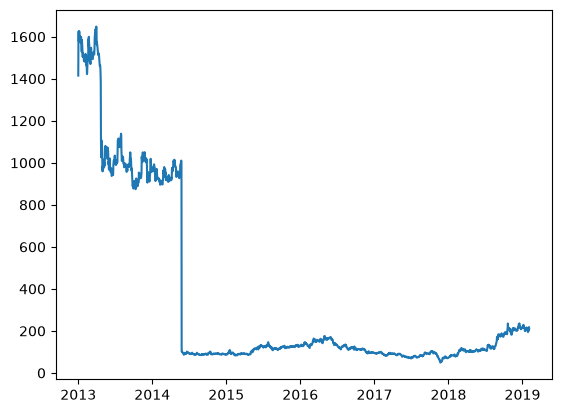

In [9]:
import matplotlib.pyplot as plt
plt.plot(dataset['Close'])

<Figure size 1600x500 with 0 Axes>

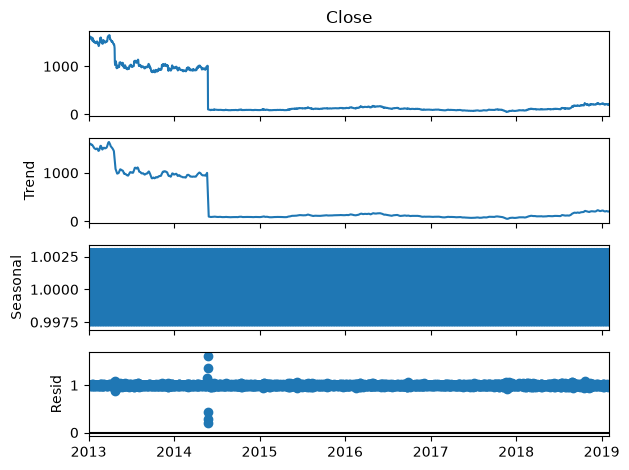

In [10]:
from pandas import read_csv
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose  #break a time series into its main components (trend,seasonal,residual,observed)
result=seasonal_decompose(dummyDate['Close'], model='multiplicative')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

Trend (T) – The long-term direction of the data (increasing, decreasing, or stable).
Seasonal (S) – Patterns that repeat at regular intervals, such as daily, monthly, quarterly, or yearly.
Residual (R) (also called Irregular or Noise) – The random variation left after removing the trend and seasonal components.
Observed (O) – The original time series data.

In [11]:
#!pip install statsmodels

<Figure size 1600x500 with 0 Axes>

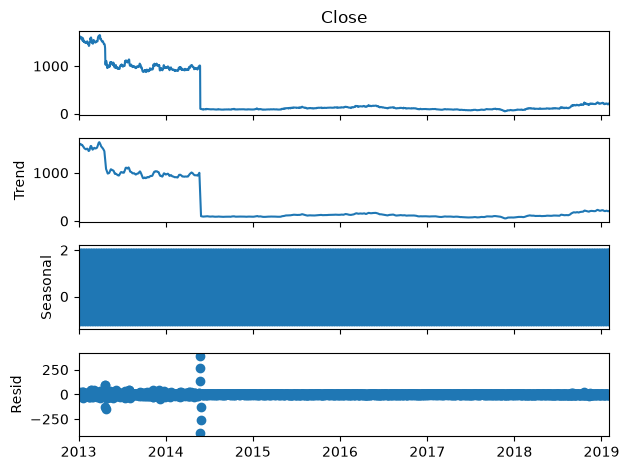

In [12]:
from pandas import read_csv
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(dummyDate['Close'], model='additive')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

In [13]:
#ADF test-to identify the series is stationarity or not

from statsmodels.tsa.stattools import adfuller
print("Results of Dicky-Fuller Test:")
dftest=adfuller(dataset['Close'],autolag="AIC")  #Akaike Information Criterion(AIC) Automatically selects the best lag length.
dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lag Used','Number of observations used'])



Results of Dicky-Fuller Test:


In [14]:
dftest

(np.float64(-3.007236327367315),
 np.float64(0.03422412229093029),
 1,
 2223,
 {'1%': np.float64(-3.433295059438173),
  '5%': np.float64(-2.8628410403669844),
  '10%': np.float64(-2.5674626062113077)},
 np.float64(19813.538287196585))

In [15]:
dfoutput

Test Statistic                   -3.007236
p-value                           0.034224
#lag Used                         1.000000
Number of observations used    2223.000000
dtype: float64

In [16]:
dftest[4].items()

dict_items([('1%', np.float64(-3.433295059438173)), ('5%', np.float64(-2.8628410403669844)), ('10%', np.float64(-2.5674626062113077))])

In [17]:
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)' %key]=value
print(dfoutput)

Test Statistic                   -3.007236
p-value                           0.034224
#lag Used                         1.000000
Number of observations used    2223.000000
Critical Value (1%)              -3.433295
Critical Value (5%)              -2.862841
Critical Value (10%)             -2.567463
dtype: float64


In [18]:
ans=dfoutput

In [19]:
print("p-value<=0.05-->Accept Alternate Hypothesis")
print("p-value>0.05-->Accept Null Hypothesis")
if(ans['Test Statistic']<ans["Critical Value (1%)"] or ans['Test Statistic']<ans["Critical Value (5%)"] or ans['Test Statistic']<ans["Critical Value (10%)"] and ans["p-value"]<0.05):
    print("Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis")
    print("Reject null hypothesis:Non Stationarity")
    print("Accept Alternate hypothesis:Staionarity ")
    message="Stationarity based on ADH"
else:
    print("Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis")
    print("Accept null hypothesis:Non Stationarity" )
    print("Reject Alternate hypothesis:Staionarity ")
    message="Non-stationarity based on ADH"

p-value<=0.05-->Accept Alternate Hypothesis
p-value>0.05-->Accept Null Hypothesis
Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis
Reject null hypothesis:Non Stationarity
Accept Alternate hypothesis:Staionarity 


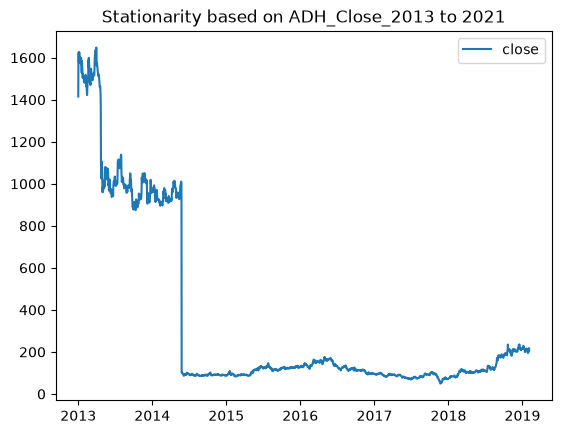

In [20]:
plt.plot(dataset.index, dataset["Close"], label = "close")
plt.legend(loc='best')
plt.title("{}_{}_2013 to 2021".format(message,"Close"))
plt.savefig("{}_ADH.png".format("Close"))
plt.show()

In [21]:
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries,df,pollutant):
    plt.figure(figsize=(16,5))
    # Plot the data
    # ADF Test
    # Function to print out results in customised manner
    from statsmodels.tsa.stattools import adfuller
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    ans=dfoutput
    print("Condition:")
    print("p-value<=0.05-->Accept Alternate Hypothesis")
    print("p-value>0.05-->Accept Null Hypothesis")
    if(ans['Test Statistic']<ans["Critical Value (1%)"] or ans['Test Statistic']<ans["Critical Value (5%)"] or ans['Test Statistic']<ans["Critical Value (10%)"] and ans["p-value"]<0.05):
        print("Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis")
        print("Reject null hypothesis:Non Stationarity")
        print("Accept Alternate hypothesis:Staionarity ")
        message="Stationarity based on ADH"
    else:
        print("Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis")
        print("Accept null hypothesis:Non Stationarity" )
        print("Reject Alternate hypothesis:Staionarity ")
        message="Non-stationarity based on ADH"
        
    plt.plot(df.index, df[pollutant], label = pollutant)
    plt.legend(loc='best')
    plt.title("{}_{}_2013 to 2021".format(message,pollutant))
    plt.savefig("{}_ADH.png".format(pollutant))
    plt.show()
    
    return message
    

Results of Dickey-Fuller Test:
Test Statistic                   -3.007236
p-value                           0.034224
#Lags Used                        1.000000
Number of Observations Used    2223.000000
Critical Value (1%)              -3.433295
Critical Value (5%)              -2.862841
Critical Value (10%)             -2.567463
dtype: float64
Condition:
p-value<=0.05-->Accept Alternate Hypothesis
p-value>0.05-->Accept Null Hypothesis
Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis
Reject null hypothesis:Non Stationarity
Accept Alternate hypothesis:Staionarity 


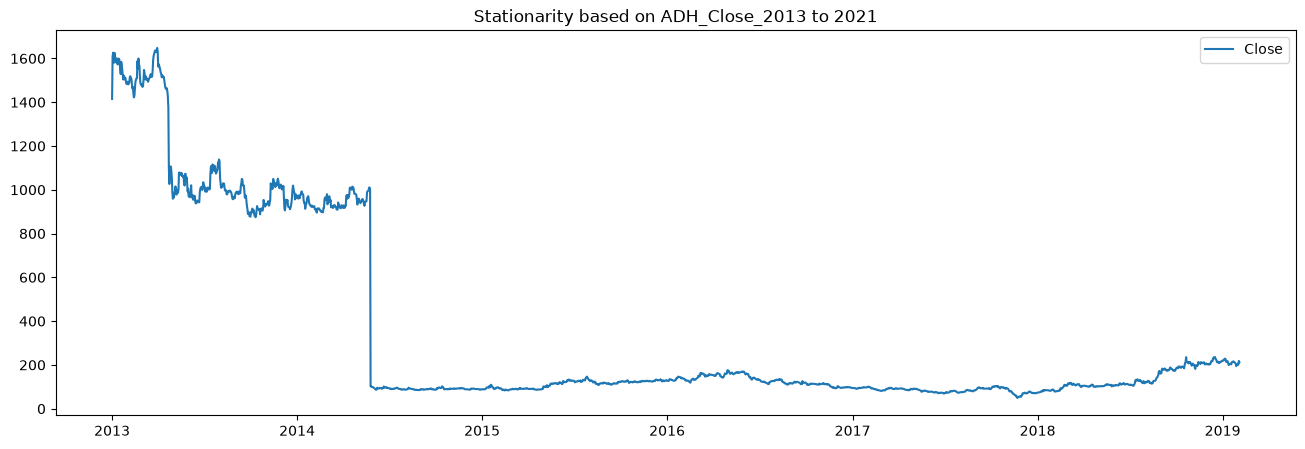

'Stationarity based on ADH'

In [22]:
adf_test(dataset["Close"],dataset,"Close")

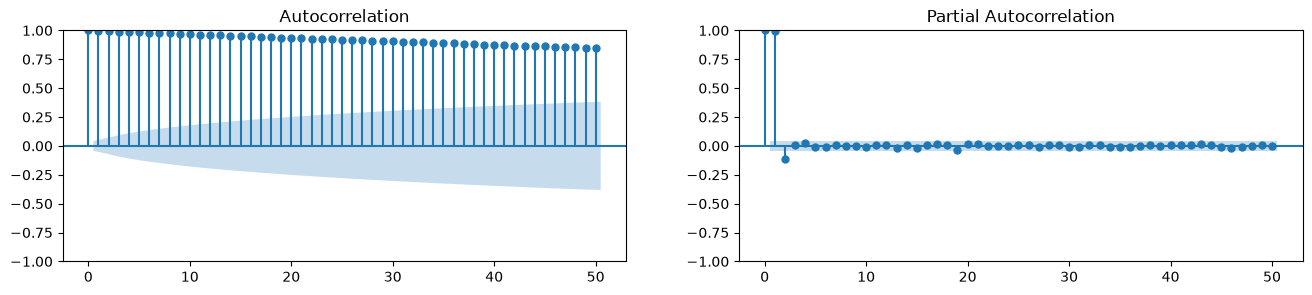

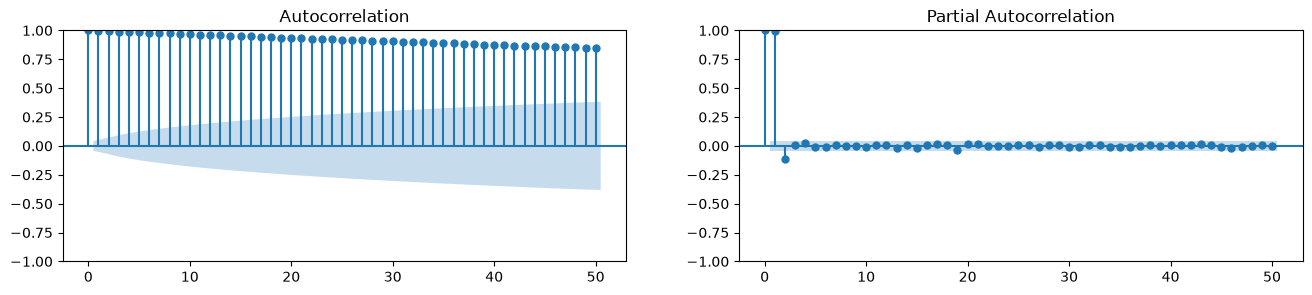

In [23]:
#ACF plot shows how strongly the current value of a time series is correlated with its previous values
#PACF plot measures the direct correlation between the current observation and a lagged observation after removing the effects of the intermediate lags.

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(dataset.Close.tolist(), lags=50, ax=axes[0])  #tolist used to convert series into python list
plot_pacf(dataset.Close.tolist(), lags=50, ax=axes[1])

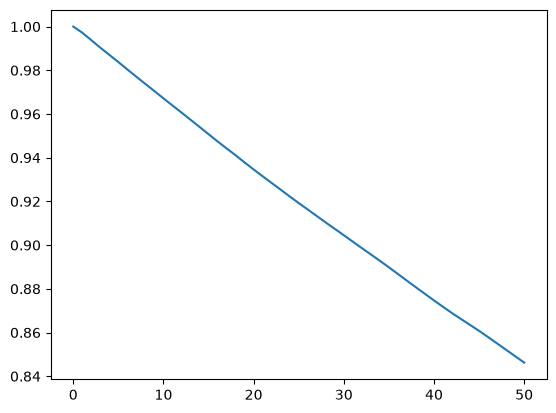

In [24]:
plt.plot(acf(dataset["Close"],nlags=50))

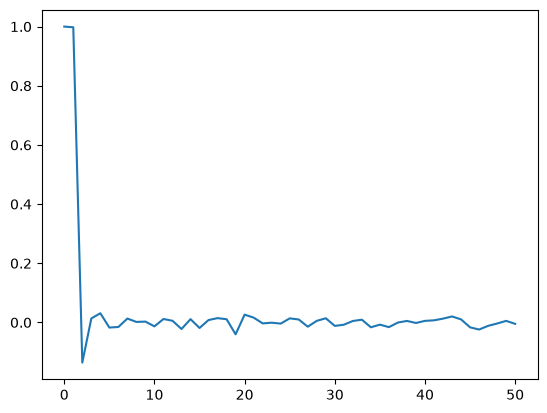

In [25]:
plt.plot(pacf(dataset["Close"],nlags=50))

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

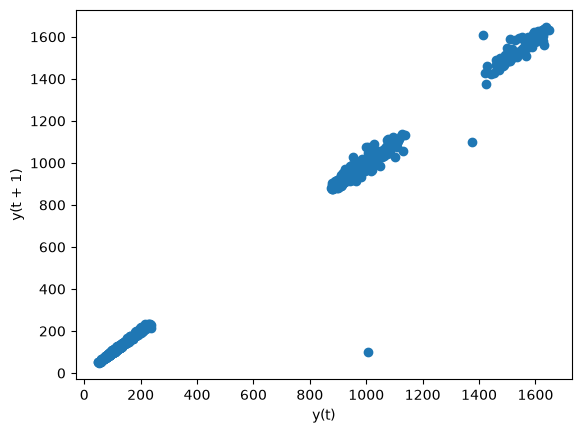

In [26]:
from pandas.plotting import lag_plot
lag_plot(dataset["Close"],lag=1)

In [27]:
#This function calculates the maximum absolute difference between two vectors.
#This is called the Chebyshev distance.

max([abs(ua - va) for ua, va in zip([2,3], [2.1,3.2])])

0.20000000000000018

In [28]:
U = [2,3,5,4,6]
N=len(U)
x = [[U[j] for j in range(i, i + 2 - 1 + 1)] for i in range(N - 2 + 1)]
x  #These are overlapping sequences of length 2.

[[2, 3], [3, 5], [5, 4], [4, 6]]

In [29]:
import numpy as np
r=0.2*np.std(dataset["Close"])
C = [len([1 for j in range(len(x)) if i != j and 0.200 <= r]) for i in range(len(x))]

In [30]:
(N - 2 + 1.0)**(-1) * sum(np.log(C))  #This is the average logarithm of the similarity counts.

np.float64(1.0986122886681098)

In [31]:
#Apen small- Forecastability is possible

def ApEn(U, m, r):
    """Compute Aproximate entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0) for x_i in x]
        return (N - m + 1.0)**(-1) * sum(np.log(C))

    N = len(U)
    return abs(_phi(m+1) - _phi(m))

In [32]:
print(ApEn(dataset["Close"].values, m=2, r=0.2*np.std(dataset["Close"])))  

#calculates the Approximate Entropy of the stock's closing prices.
#Here, dataset["Close"] is the input time series, m=2 means patterns of two consecutive values are compared, 
#and r=0.2 × standard deviation defines the similarity threshold. 
#The function returns a measure of the series' complexity

0.027409184525792107


In [33]:
def SampEn(U, m, r):
    """Compute Sample entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for j in range(len(x)) if i != j and _maxdist(x[i], x[j]) <= r]) for i in range(len(x))]
        return sum(C)

    N = len(U)
    return -np.log(_phi(m+1) / _phi(m))

In [38]:
print(SampEn(dataset["Close"].values, m=2,r=0.2*np.std(dataset["Close"])))

0.007918086989927514
